In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict
from data import *
from data_utils import f_ground_truth, add_corresponding_terms
from information_content import deprecated, compute_information_content, get_ancestors0

/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


ncbi_gene_id              str
gene_symbol               str
association_type          str
disease_id                str
#string_protein_id        str
annotation                str
protein2                  str
combined_score        float64
dtype: object

1
2
3


# Statistiques descriptives sur l'arbre HPO

<Axes: >

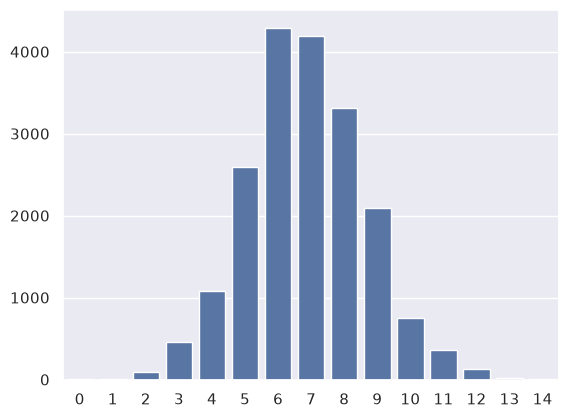

In [2]:
n_nodes = G_hpo_work.number_of_nodes()
n_edges = G_hpo_work.number_of_edges()

prof = [v for v in depths.values()]
x,y = np.unique(prof, return_counts=True)
sns.set_theme()
sns.barplot(x=x,y=y)

In [2]:
import pandas as pd
out_deg = [v for v in dict(G_hpo_work.in_degree()).values()]
print("Nombre d'enfants")
print(f"Moyen :{np.mean(out_deg)},\n Max : {np.max(out_deg)},\n Min : {np.min(out_deg)},\n Std : {np.std(out_deg)}")
df = pd.read_csv("../data/HPOs.csv", sep=";")

Nombre d'enfants
Moyen :1.2210819452323243,
 Max : 193,
 Min : 0,
 Std : 3.375027598225367


In [3]:
# Les 7 sous ontologies
inheritance = nx.ancestors(G_hpo_work, 'HP:0000005')
print(len(list(inheritance)))
onset = nx.ancestors(G_hpo_work, 'HP:0012823')
print(len(list(onset)))
abnormality = nx.ancestors(G_hpo_work, 'HP:0000118')
print(len(list(abnormality)))
history = nx.ancestors(G_hpo_work, 'HP:0032443')
print(len(list(history)))
biospecimen = nx.ancestors(G_hpo_work, 'HP:0020228')
print(len(list(biospecimen)))
blood = nx.ancestors(G_hpo_work, 'HP:0032223')
print(len(list(blood)))
frequency = nx.ancestors(G_hpo_work, 'HP:0040279')
print(len(list(frequency)))
print(len(G_hpo_work.nodes))
categories = {
    'inheritance': list(inheritance), 
    'onset' : list(onset), 
    'abnormality' : list(abnormality), 
    'history' : list(history), 
    'biospecimen' : list(biospecimen),
    'blood' : list(blood), 
    'frequency' : list(frequency)}

40
357
18690
198
85
8
6
19391


# Statistiques descriptives sur les maladies hpoa

In [2]:
# Maladies tirées de hpo-jax.org
work_omim = work_omim.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha = work_orpha.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols = [c for c in work_omim.columns if c.startswith("HP:")]
print(f"Nombre de maladies OMIM, {work_omim.shape[0]}, nombre de maladies Orphanet, {work_orpha.shape[0]}")

# Maladies Orpha tirées directement d'Orphanet
work_orpha2 = work_orpha2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_omim2 = work_omim2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols2 = [c for c in work_orpha2.columns if c.startswith('HP')]
print(f"Nombre de maladies OMIM, {work_omim2.shape[0]}, nombre de maladies Orphanet, {work_orpha2.shape[0]}")

gt_set, valid_omim, valid_orpha = f_ground_truth(work_omim, work_orpha, df_orpha_omim_exact)
gt_set2, valid_omim2, valid_orpha2 = f_ground_truth(work_omim2, work_orpha2, df_orpha_omim_exact)

# Formes matricielles
X_omim = work_omim[hpo_cols].astype(int).values    # shape (n_omim, n_hpo)
X_orpha = work_orpha[hpo_cols].astype(int).values  # shape (n_orpha, n_hpo)

n_omim = X_omim.sum(axis=1)    
m_orpha = X_orpha.sum(axis=1) 

Nombre de maladies OMIM, 6686, nombre de maladies Orphanet, 3189
Nombre de maladies OMIM, 6686, nombre de maladies Orphanet, 3211


In [3]:
# Propagation ancestrale
import tsw
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols}
w_omim_P = tsw.propagate_terms(work_omim,  hpo_cols, ancestors, depths, k=3)
w_orpha_P = tsw.propagate_terms(work_orpha, hpo_cols, ancestors, depths, k=3)

#w_omim_P2 = tsw.propagate_terms(work_omim2,  hpo_cols2, ancestors, depths, k=3)
#w_orpha_P2 = tsw.propagate_terms(work_orpha2, hpo_cols2, ancestors, depths, k=3)

# Formes matricielles
X_omimP = w_omim_P[hpo_cols].astype(int).values    # shape (n_omim, n_hpo)
X_orphaP = w_orpha_P[hpo_cols].astype(int).values  # shape (n_orpha, n_hpo)

n_omimP = X_omimP.sum(axis=1)    
m_orphaP = X_orphaP.sum(axis=1) 

### Distributions des termes par sous-ontologie

In [29]:
def term_categorie(df, node2id, categories):
    hpo_cols = [c for c in df.columns if c.startswith('HP')]
    id2idx = {node2id[hpo_cols[i]]: i for i in range(len(hpo_cols))}
    resultats = {cat: 0 for cat in categories.keys()}
    ids = defaultdict(list)
    for name, cat in categories.items():
        ids[name] = [
            id2idx[node2id[u]]
            for u in cat
            if u in node2id and node2id[u] in id2idx
        ]
    X = df[hpo_cols].values
    n = df.shape[0]
    for i in range(n):
        for cat in categories.keys():
            resultats[cat] += int(np.sum(X[i, ids[cat]]) > 0)
    taux = {cat: round(100 * count / n, 1) for cat, count in resultats.items()}
    return taux

taux_omim = term_categorie(work_omim.reset_index(drop=True), node2id_w, categories)
taux_orpha = term_categorie(work_orpha.reset_index(drop=True), node2id_w, categories)
taux_orpha2 = term_categorie(work_orpha2.reset_index(drop=True), node2id_w, categories)

taux_omim, taux_orpha, taux_orpha2

({'inheritance': 98.9,
  'onset': 59.6,
  'abnormality': 99.9,
  'history': 0.4,
  'biospecimen': 0.0,
  'blood': 0.0,
  'frequency': 0.0},
 {'inheritance': 0.0,
  'onset': 2.2,
  'abnormality': 100.0,
  'history': 1.5,
  'biospecimen': 0.0,
  'blood': 0.0,
  'frequency': 0.0},
 {'inheritance': 0.0,
  'onset': 2.2,
  'abnormality': 100.0,
  'history': 1.5,
  'biospecimen': 0.0,
  'blood': 0.0,
  'frequency': 0.0})

### Termes actifs

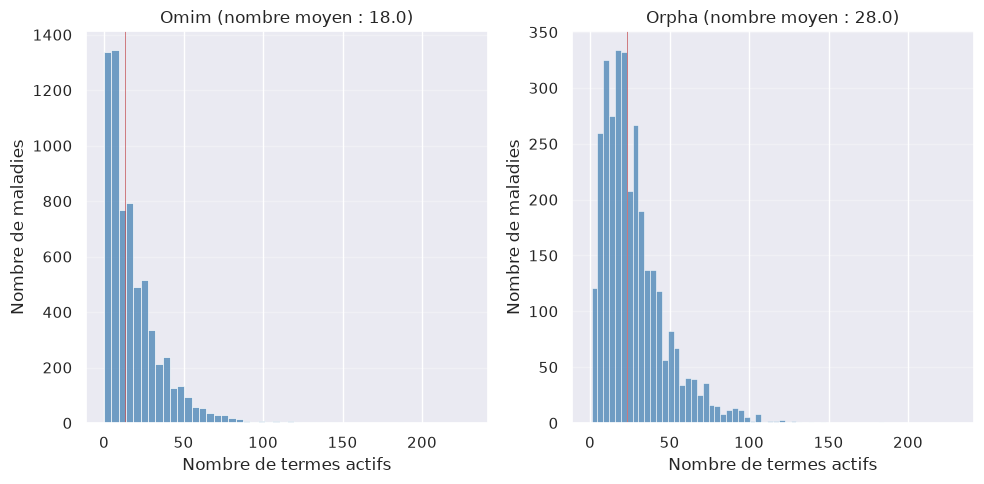

In [7]:
sns.set_theme()
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax = axes[0]
sns.histplot(n_omim, bins=50, ax=ax, color='steelblue')

ax.axvline(np.median(n_omim), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title(f"Omim (nombre moyen : {np.mean(n_omim).round(0)})")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(m_orpha, bins=50, ax=ax, color='steelblue')

ax.axvline(np.median(m_orpha), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title(f"Orpha (nombre moyen : {np.mean(m_orpha).round(0)})")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Termes actifs en commun entre maladies jumelles

In [11]:
# Sans propagation ancestrale
common_matrix = X_omim @ X_orpha.T

gt_df = pd.DataFrame(list(gt_set), columns=['omim_pos', 'orpha_pos'])

omim_pos = gt_df['omim_pos'].values
orpha_pos = gt_df['orpha_pos'].values

gt_df['termes_communs'] = common_matrix[omim_pos, orpha_pos]
gt_df['n_omim'] = n_omim[omim_pos]
gt_df['m_orpha'] = m_orpha[orpha_pos]

denom = gt_df['n_omim'] + gt_df['m_orpha']
gt_df['score'] = np.where(denom > 0, 2 * gt_df['termes_communs'] / denom, np.nan)

# Récupérer les vrais identifiants pour lecture/export
gt_df['omim_id'] = work_omim['database_id'].values[omim_pos]
gt_df['orpha_id'] = work_orpha['database_id'].values[orpha_pos]

df_scores = gt_df[['omim_id', 'orpha_id', 'n_omim', 'm_orpha', 'termes_communs', 'score']]
print(df_scores.describe())
df_scores.head()

            n_omim      m_orpha  termes_communs        score
count  2217.000000  2217.000000     2217.000000  2217.000000
mean     22.799278    27.464592        8.774470     0.328206
std      20.957944    20.191161        8.308504     0.169264
min       0.000000     2.000000        0.000000     0.000000
25%       8.000000    13.000000        3.000000     0.214286
50%      17.000000    22.000000        6.000000     0.322581
75%      31.000000    36.000000       12.000000     0.434783
max     193.000000   185.000000       59.000000     1.000000


,omim_id,orpha_id,n_omim,m_orpha,termes_communs,score
0,OMIM:201180,ORPHA:1784,28,29,8,0.280702
1,OMIM:249600,ORPHA:2557,11,32,3,0.139535
2,OMIM:602484,ORPHA:2840,11,10,0,0.000000
3,OMIM:231680,ORPHA:26791,42,57,18,0.363636
4,OMIM:214800,ORPHA:138,89,94,37,0.404372


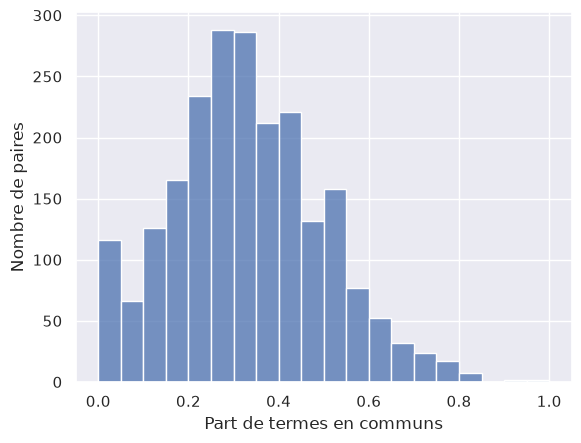

In [23]:
sns.set_theme()
sns.histplot(df_scores['score'], bins=20)

plt.xlabel("Part de termes en communs")
plt.ylabel("Nombre de paires")
plt.show()

In [13]:
# Avec propagation ancestrale
common_matrix = X_omimP @ X_orphaP.T

gt_df = pd.DataFrame(list(gt_set), columns=['omim_pos', 'orpha_pos'])

omim_pos = gt_df['omim_pos'].values
orpha_pos = gt_df['orpha_pos'].values

gt_df['termes_communs'] = common_matrix[omim_pos, orpha_pos]
gt_df['n_omim'] = n_omimP[omim_pos]
gt_df['m_orpha'] = m_orphaP[orpha_pos]

denom = gt_df['n_omim'] + gt_df['m_orpha']
gt_df['score'] = np.where(denom > 0, 2 * gt_df['termes_communs'] / denom, np.nan)

# Récupérer les vrais identifiants pour lecture/export
gt_df['omim_id'] = w_omim_P['database_id'].values[omim_pos]
gt_df['orpha_id'] = w_orpha_P['database_id'].values[orpha_pos]

df_scores = gt_df[['omim_id', 'orpha_id', 'n_omim', 'm_orpha', 'termes_communs', 'score']]
print(df_scores.describe())
df_scores.head()

            n_omim      m_orpha  termes_communs        score
count  2217.000000  2217.000000     2217.000000  2217.000000
mean     81.497068    94.104195       47.691024     0.519354
std      68.522178    63.907872       38.969981     0.172389
min       0.000000     4.000000        0.000000     0.000000
25%      32.000000    47.000000       19.000000     0.417266
50%      62.000000    79.000000       37.000000     0.531469
75%     111.000000   124.000000       65.000000     0.631579
max     505.000000   520.000000      291.000000     1.000000


,omim_id,orpha_id,n_omim,m_orpha,termes_communs,score
0,OMIM:201180,ORPHA:1784,139,142,77,0.548043
1,OMIM:249600,ORPHA:2557,64,124,43,0.457447
2,OMIM:602484,ORPHA:2840,50,44,15,0.319149
3,OMIM:231680,ORPHA:26791,141,168,88,0.569579
4,OMIM:214800,ORPHA:138,323,312,192,0.604724


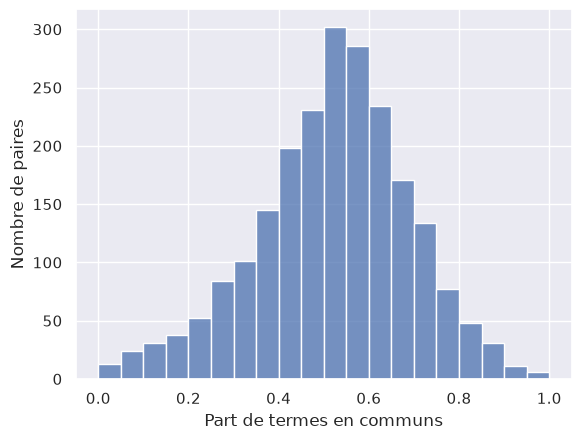

In [15]:
sns.set_theme()
sns.histplot(df_scores['score'], bins=20)

plt.xlabel("Part de termes en communs")
plt.ylabel("Nombre de paires")
plt.show()

### Profondeur maximale des termes HPO des maladies

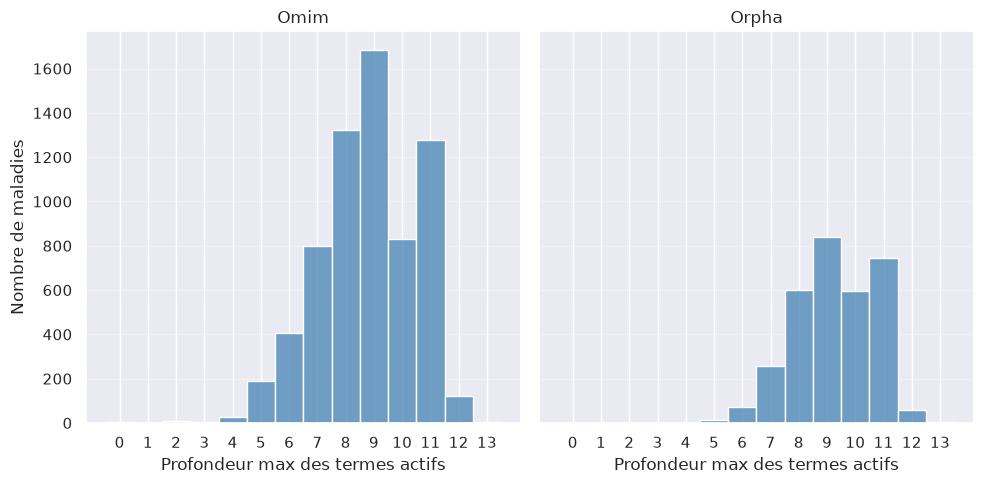

In [14]:
depths_cols = [depths[t] for t in hpo_cols]
max_depths_omim = np.max(X_omim*depths_cols, axis=1)
max_depths_orpha = np.max(X_orpha*depths_cols, axis=1)

vmin = min(max_depths_omim.min(), max_depths_orpha.min())
vmax = max(max_depths_omim.max(), max_depths_orpha.max())

# bins centrés sur les entiers
bin_edges = np.arange(vmin, vmax + 2) - 0.5
bin_centers = np.arange(vmin, vmax + 1)  # = centres des bins = valeurs entières

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
sns.set_theme()

for ax, data, title in zip(axes, [max_depths_omim, max_depths_orpha], ["Omim", "Orpha"]):
    sns.histplot(data, ax=ax, color='steelblue', bins=bin_edges)
    ax.set_xlabel("Profondeur max des termes actifs")
    ax.set_ylabel("Nombre de maladies")
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(bin_centers)  # <-- force une graduation par bin/valeur entière

plt.tight_layout()
plt.show()

In [8]:
id_omim = [i for (i,j) in gt_set]
id_orpha = [j for (i,j) in gt_set]
X_omim_valid = X_omim[id_omim, :]
X_orpha_valid = X_orpha[id_orpha, :]
print(X_omim_valid.shape, X_orpha_valid.shape)

(2217, 11524) (2217, 11524)


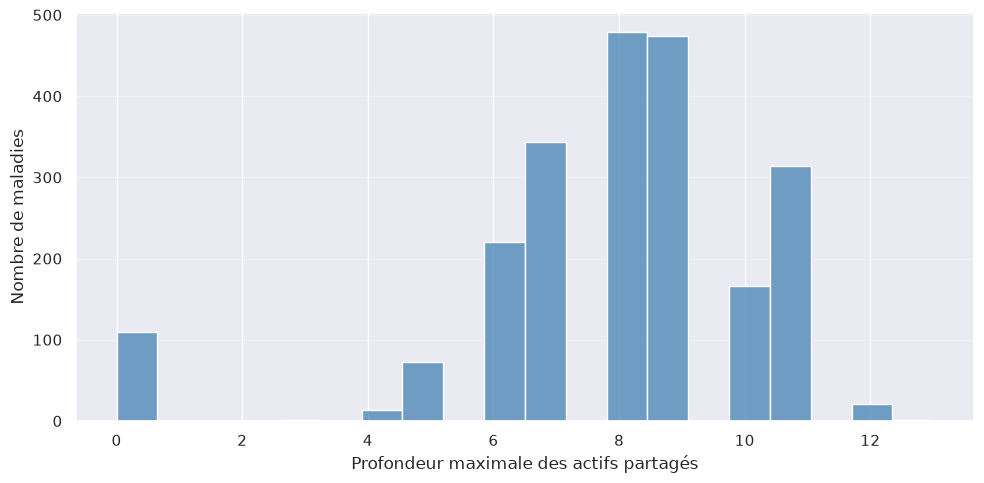

In [ ]:
communs = X_omim_valid*X_orpha_valid
max_shared_depths = np.max(communs * depths_cols, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(max_shared_depths, bins=20, ax=ax, color='steelblue')

ax.set_xlabel("Profondeur maximale des termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### *Information content*

In [16]:
weights_omim, _, _ = compute_information_content(work_omim, G_hpo_work)
weights_omim = {t:-np.log(w) for t, w in weights_omim.items()}

weights_orpha, _, _ = compute_information_content(work_orpha, G_hpo_work)
weights_orpha = {t:-np.log(w) for t, w in weights_orpha.items()}

union_diseases = add_corresponding_terms(work_omim, work_orpha, df_orpha_omim_exact)
remaining_orpha = work_orpha[~work_orpha['database_id'].isin(valid_orpha)]
print(union_diseases.shape, remaining_orpha.shape)
all_diseases = pd.concat([union_diseases, remaining_orpha])
weights_all,_, _ = compute_information_content(all_diseases, G_hpo_work)
weights_all = {t:-np.log(w) for t, w in weights_all.items()}

Fusion HPO: 100%|██████████| 2217/2217 [00:00<00:00, 6795.81it/s]


(6686, 11525) (972, 11525)


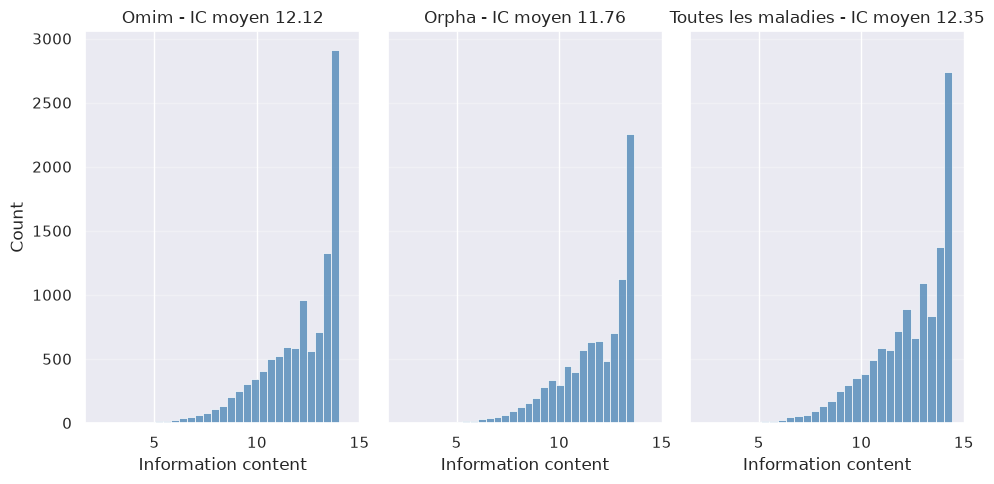

In [23]:
sns.set_theme()
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(weights_omim, bins=30, ax=ax, color='steelblue')

ax.set_xlabel("Information content")
ax.set_title(f"Omim - IC moyen {round(np.mean(list(weights_omim.values())),2)}")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(weights_orpha, bins=30, ax=ax, color='steelblue')

ax.set_xlabel("Information content")
ax.set_title(f"Orpha - IC moyen {round(np.mean(list(weights_orpha.values())),2)}")
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
sns.histplot(weights_all, bins=30, ax=ax, color='steelblue')

ax.set_xlabel("Information content")
ax.set_title(f"Toutes les maladies - IC moyen {round(np.mean(list(weights_all.values())),2)}")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()